In [40]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import rpa_control.models
import rpa_control.strategies
import rpa_control.strategies.sot
importlib.reload(rpa_control.models)
importlib.reload(rpa_control.strategies.sot)
importlib.reload(rpa_control.strategies)
from rpa_control.models import (
    model_if, model_iffl,
    model_abc_fbA_pos, model_abc_fbA_neg, model_abc_fbB_pos, model_abc_fbB_neg,
)
from rpa_control.strategies import run_sot_demo, SeparationOfTimescalesStrategy
from rpa_control import simulation

Different options for feedback from the cancer to the AB system: positive negative arrows to either A or B.

In [41]:
mu  = 1.0
a1  = 1.0
b1  = 1.0       # off-treatment
b1_on = b1 / 2  # on-treatment (drug halves b1)
b2  = 2.0
b3 = 0.5        # feedback strength c->B
c1  = 0.05      # tumor growth rate
c2  = 1.0       # tumor removal rate

def abc_rhs_no_feedback(t, y, b1_val):
    A, B, C = y
    dA = a1 * (mu - B)
    dB = b1_val * A - b2 * B
    dC = C * (c1 - c2 * max(mu - B, 0.0))
    return [dA, dB, dC]

def abc_rhs_B_feedback(t, y, b1_val):
    A, B, C = y
    dA = a1 * (mu - B)
    dB = b1_val * A - b2 * B - b3 * C
    dC = C * (c1 - c2 * max(mu - B, 0.0))
    return [dA, dB, dC]

We want to apply the sot strategy to the system with feedback. Test for different feedback strengths b3 and see when it is possible and impossible to shrink the tumor.

In [42]:
# first apply the strategy once to test
# what is considered a successful strategy? We can say C_final / C_initial > 1 => tumor growth, C_final / C_initial < 1 => tumor shrinkage.
# model_if is exactly the AB(+Cancer) system — no need for a separate ABC model.

sot_abc = SeparationOfTimescalesStrategy(model_if)
print(f"O* = {sot_abc.O_star:.4f}  |  RPA params: {model_if.rpa_params}")

# 'beta1' is the treatment parameter (analogous to b1); scale='0.5x' halves it
T_on, T_off = sot_abc.simulate('beta1', scale='0.5x', n_cycles=5, t_max_ton=15, t_max_toff=15)
# (self, param, scale='2x', n_cycles=5, recovery_frac=0.9,
                #  dt=0.005, t_max_ton=200, t_max_toff=500)

res = sot_abc.results['beta1']['0.5x']
if res['success']:
    cidx = sot_abc._cancer_idx
    C_traj = res['y_periodic'][cidx]
    C_initial, C_final = C_traj[0], C_traj[-1]
    ratio = C_final / C_initial
    outcome = "tumor growth" if ratio > 1 else "tumor shrinkage"
    print(f"T_on = {T_on:.3f}, T_off = {T_off:.3f}")
    print(f"C_initial = {C_initial:.4f}, C_final = {C_final:.4f}, ratio = {ratio:.4f} -> {outcome}")
else:
    print("Strategy not successful: Cancer does not decay under constant treatment.")

O* = 1.0000  |  RPA params: ['alpha', 'beta1', 'beta2']
T_on = 4.985, T_off = 2.180
C_initial = 1.0000, C_final = 0.0438, ratio = 0.0438 -> tumor shrinkage


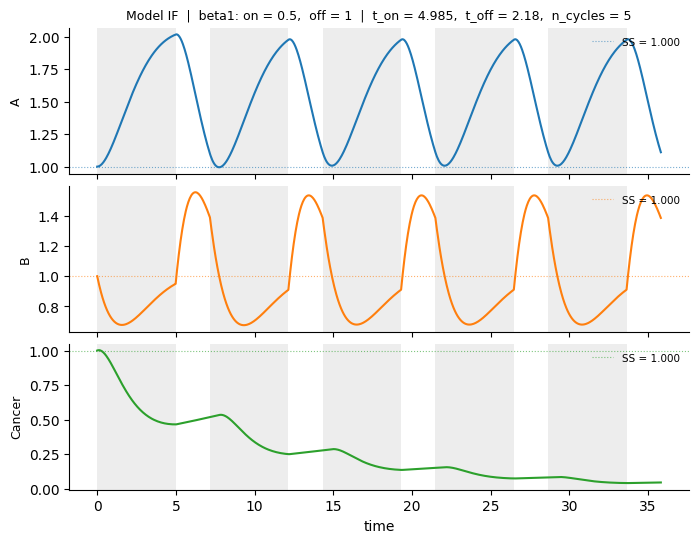

In [43]:
# reuse the existing generic plotting utilities instead of hand-rolling the figure
if res['success']:
    t_all, y_all = simulation.simulate_rpa_intermittent(
        model_if, 'beta1',
        on_value=res['param_val'], off_value=model_if.params_base['beta1'],
        t_on=res['T_on'], t_off=res['T_off'], n_cycles=5,
    )
else:
    # no T_on/T_off available; just show the constant-treatment trajectory
    t_all, y_all = simulation.stepped_trajectory(
        model_if, 'beta1', values=[res['param_val']], durations=[200],
    )

Now the 4 feedback configurations: Cancer feeding into `A` or `B`, with a positive or negative sign, each swept over a range of feedback strengths `b3`. Each config is a `FeedbackModel` wrapping `model_if` (purely numerical — see `rpa_control.models.FeedbackModel`), so `SeparationOfTimescalesStrategy` still auto-determines `T_on`/`T_off` for every run.

In [44]:
feedback_configs = {
    'A+': model_abc_fbA_pos,
    'A-': model_abc_fbA_neg,
    'B+': model_abc_fbB_pos,
    'B-': model_abc_fbB_neg,
}
b3_values = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0]

feedback_results = {label: [] for label in feedback_configs}
for label, model in feedback_configs.items():
    for b3 in b3_values:
        model.params_base['b3'] = b3
        sot = SeparationOfTimescalesStrategy(model)
        T_on, T_off = sot.simulate('beta1', scale='0.5x', n_cycles=5)

        res = sot.results['beta1']['0.5x']
        ratio = None
        if res['success']:
            cidx  = sot._cancer_idx
            C_traj = res['y_periodic'][cidx]
            ratio = C_traj[-1] / C_traj[0]

        feedback_results[label].append(dict(b3=b3, success=res['success'], ratio=ratio))
        outcome = 'n/a' if ratio is None else ('growth' if ratio > 1 else 'shrinkage')
        print(f"{label:3s} b3={b3:>4.2f}  success={res['success']!s:5s}  ratio={ratio}  -> {outcome}")

A+  b3=0.00  success=True   ratio=0.04382113236330812  -> shrinkage
A+  b3=0.25  success=True   ratio=0.3738316414905194  -> shrinkage
A+  b3=0.50  success=True   ratio=2.431407422458992e+54  -> growth
A+  b3=1.00  success=True   ratio=2.3343155763008548e+54  -> growth
A+  b3=2.00  success=True   ratio=2.1924608834995653e+54  -> growth
A+  b3=4.00  success=False  ratio=None  -> n/a
A-  b3=0.00  success=True   ratio=0.04382113236330812  -> shrinkage
A-  b3=0.25  success=True   ratio=0.22045699662857363  -> shrinkage
A-  b3=0.50  success=True   ratio=0.11022849831428681  -> shrinkage
A-  b3=1.00  success=True   ratio=0.055114249157143406  -> shrinkage
A-  b3=2.00  success=True   ratio=0.0011847078443021518  -> shrinkage
A-  b3=4.00  success=True   ratio=0.0001406893272079082  -> shrinkage
B+  b3=0.00  success=True   ratio=0.04382113236330812  -> shrinkage
B+  b3=0.25  success=True   ratio=0.13856545397604345  -> shrinkage
B+  b3=0.50  success=False  ratio=None  -> n/a
B+  b3=1.00  succes

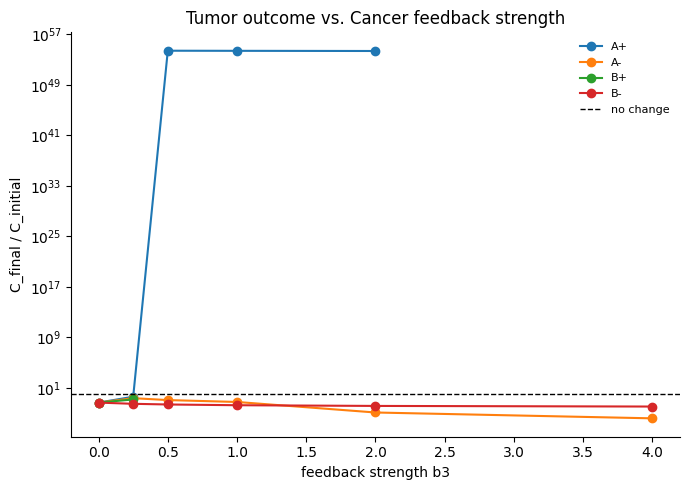

In [45]:
plt.figure(figsize=(7, 5))
for label, runs in feedback_results.items():
    b3s    = [r['b3'] for r in runs]
    ratios = [r['ratio'] if r['ratio'] is not None else np.nan for r in runs]
    plt.plot(b3s, ratios, marker='o', label=label)

plt.axhline(1.0, color='k', ls='--', lw=1, label='no change')
plt.yscale('log')
plt.xlabel('feedback strength b3')
plt.ylabel('C_final / C_initial')
plt.title('Tumor outcome vs. Cancer feedback strength')
plt.legend(fontsize=8, frameon=False)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()